# What do the SARS-Cov-2 genes do?


One process in the analysis of a new organism is annotating the genome. The first step of this analysis is to find potential genes through identifying open reading frames (ORFs). 
After this, the next question is which of these correspond to actual genes?

To answer this, we will lean on what we know about evolution. If two species are morphologically different, their genetic material must also differ substantially. Right? Not exactly. Evolution conserved many genes crucial for survival. The degree of conservation is surprising. For example, while we would expect to share many genes with the chimpanzee, our closest relative, we would expect almost no similarity in our genetic material with bananas. The numbers tell us otherwise. While sharing 96% of our genes with the chimpanzee, we also share 60% of our genes with bananas! These similar genes in humans and bananas encode proteins that carry similar functions.

Two genes with similar sequences may perform similar functions. Genes like these are called homologous genes. Or, more precisely, in our case, these would be orthologous genes (see the figure below). A pair of orthologous genes are genes from two related species originating from a common ancestor (e.g., humans and chimpanzees). Due to the evolution, the two nucleotide or protein sequences might differ slightly but not overwhelmingly.

<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d8/Ortholog_paralog_analog_%28homologs%29.svg/1200px-Ortholog_paralog_analog_%28homologs%29.svg.png" width="500">
</div>

*Author: Thomas Shafee, Licence: CC BY 4.0*

The human-banana example demonstrates that these two organisms don't have to be that closely related! If we tried to determine the gene function in humans using bananas as a reference, we could infer the role of over 60% of the genes. However, using two closely related organisms would undoubtedly give us more robust results. We would be better off choosing the genome of a mouse or a chimpanzee as our reference.

Scientists have studied hundreds of viruses and determined the functions of most of their genes. Using viruses similar in sequence to SARS-Cov-2, we can characterize the SARS-CoV-2 ORFs to determine if they are the actual genes, and think about their function. Knowing what each gene does might help us find a way to fight the infection and potentially even find treatments for COVID-19. 

#### Please ensure each answer is completed in the single cell of the notebook immediately following the question, and that all answers are in ```markdown``` format.

Once you have completed the notebook, make sure you save it and submit it via Moodle.

All questions are worth between 4 and 10 marks. There are a total of *40 marks* available in this workbook. There is an extra bonus problem for *10 marks*. 
  
Total notebook marks will be scaled to a **course mark out of 10** to contribute to your course total.

In [1]:
import numpy as np
from Bio import Entrez

In [2]:
# In order to import from the python file without hassle, we add the current
# directory to the python path
import sys; sys.path.append(".")

Let's let the nice folks at NCBI know who we are.

In [3]:
Entrez.email = "z5588493@student.unsw.edu.au"

## Finding SARS-CoV-2's closest relatives

In the first part of this assignment, we will analyze several coronavirus genomes to determine which are most similar to SARS-CoV-2. We will then use the viruses with the most similar sequence as reference genomes to assign functions to SARS-CoV-2 ORFs.

To find the closest reference genomes, we will align the SARS-CoV-2 sequence to each candidate coronavirus genome. The virus genomes with the highest alignment scores will be our most closely-related viruses.

Notice that computing an alignment between two sequences of length $N$ and $M$ requires the computation of a dynamic programming table with $N \cdot M$ entries. The size of this matrix is sufficiently small for short sequences. But even the short genomes, like viral genomes, are generally too long for this approach. Instead of computing similarities from the entire genomes, we will only focus on the spike protein sequence. In general, we would prefer to align the whole nucleotide sequences, but for this assignment, considering only a spike protein will be sufficient. The spike protein is also one of the essential parts of any coronavirus, as it is the one that grants the virus entry to host cells. 

Considering spike proteins alone reduces the sequence lengths from ~30k (entire virus) to around 1.3k (spike protein). Nevertheless, do your best to write fast, efficient Python code. Each `global_alignment` call on 1.3k long protein sequences should take around 30 to 60 seconds. 
We have to calculate 20 comparisons, which takes roughly 10 to 20 minutes.

In [4]:
accession_codes = {
    # 6 known human coronaviruses
    "Human-SARS": "NC_004718",
    "Human-MERS": "NC_019843",
    "Human-HCoV-OC43": "NC_006213",
    "Human-HCoV-229E": "NC_002645",
    "Human-HCoV-NL63": "NC_005831",
    "Human-HCoV-HKU1": "NC_006577",
    
    # Bat
    "Bat-CoV MOP1": "EU420138",
    "Bat-CoV HKU8": "NC_010438",
    "Bat-CoV HKU2": "NC_009988",
    "Bat-CoV HKU5": "NC_009020",
    "Bat-CoV RaTG13": "MN996532",
    "Bat-CoV-ENT": "NC_003045",
    
    # Other animals
    "Hedgehog-CoV 2012-174/GER/2012": "NC_039207",
    "Pangolin-CoV MP789": "MT121216",
    "Rabbit-CoV HKU14": "NC_017083",
    "Duck-CoV isolate DK/GD/27/2014": "NC_048214",
    "Feline infectious peritonitis virus": "NC_002306",  # cat
    "Giraffe-CoV US/OH3/2003": "EF424623",
    "Murine-CoV MHV/BHKR_lab/USA/icA59_L94P/2012": "KF268338",  # mouse
    "Equine-CoV Obihiro12-2": "LC061274",  # horse
}

Above is the list of coronaviruses and their corresponding NCBI accession codes that we will consider in this assignment. You can find the SARS-CoV-2 sequence in `data/sars_cov_2.fa`. This time, we will use the FASTA format to familiarize ourselves with the sequence file formats used in bioinformatics. You can easily read FASTA files using the `SeqIO.read` function from `biopython`.

We will only use part of the sequence, and to assess similarity, consider the spike protein alone. We will assume that we know the location of the spike protein in SARS-CoV-2 (strand=1, start=21562, stop=25384). We need to find a part of the sequence that encodes for the spike protein in all coronaviruses listed above. We can inspect each sequence's features to locate the spike protein. For this assignment, we will iterate through gene coding regions (CDS) for each coronavirus and find the one that codes for the "S" gene. Some coronaviruses do not include such annotation but instead report on a "spike protein" in the `product` field.

## Problem 1: Global alignment

**Task:** Use the template `global_alignment` function in the helper file to implement the Needleman-Wunsch algorithm for global sequence alignment. Use a "-" character for indels. Score the alignments using the BLOSUM62 substitution matrix. You can find it in `biopython`.

**[10 points]**

In [5]:
from Bio import SeqIO

# Function that loops through features and returns the feature associated with spike protein
def find_spike_protein(all_features):
    for feature in all_features:
        if feature.type != 'CDS':
            continue
            
        if "gene" in feature.qualifiers:
            if feature.qualifiers["gene"][0] == 'S':
                return (feature)
        elif "product" in feature.qualifiers:
            if feature.qualifiers["product"][0] == 'spike protein':
                return (feature)

    return None

In [6]:
from Bio import Seq
import importlib
import helper_functions

importlib.reload(helper_functions)


# Extract and translate protein sequence of spike protein for SARS-CoV-2
record = SeqIO.read("data/sars_cov_2.fa", "fasta")
sars_cov_2_seq = record.seq[21562:25384]
sars_cov_2_protein = Seq.translate(sars_cov_2_seq, cds=True)

# Extracts sequence of spike protein for other coronavirus and aligns using Needleman-Wunsch
# Prints each virus as it is being aligned
total_global_alignments = {}
for name in accession_codes.keys():
    code = accession_codes[name]
    print(name, code)
    get_fasta = Entrez.efetch(db="nucleotide", id=code, rettype="genbank", retmode="text")
    record = SeqIO.read(get_fasta, "genbank")
    seq2_spike_protein = find_spike_protein(record.features).qualifiers["translation"][0]
    
    alignment = helper_functions.global_alignment(sars_cov_2_protein, seq2_spike_protein, helper_functions.blosum62_scoring_function)
    total_global_alignments[name] = alignment[2]

Human-SARS NC_004718
Human-MERS NC_019843
Human-HCoV-OC43 NC_006213
Human-HCoV-229E NC_002645
Human-HCoV-NL63 NC_005831
Human-HCoV-HKU1 NC_006577
Bat-CoV MOP1 EU420138
Bat-CoV HKU8 NC_010438
Bat-CoV HKU2 NC_009988
Bat-CoV HKU5 NC_009020
Bat-CoV RaTG13 MN996532
Bat-CoV-ENT NC_003045
Hedgehog-CoV 2012-174/GER/2012 NC_039207
Pangolin-CoV MP789 MT121216
Rabbit-CoV HKU14 NC_017083
Duck-CoV isolate DK/GD/27/2014 NC_048214
Feline infectious peritonitis virus NC_002306
Giraffe-CoV US/OH3/2003 EF424623
Murine-CoV MHV/BHKR_lab/USA/icA59_L94P/2012 KF268338
Equine-CoV Obihiro12-2 LC061274


In [9]:
# Prints all scores in descending order for global alignment
sorted_global = sorted(total_global_alignments, key=total_global_alignments.get, reverse=True)
for name in sorted_global:
    print(f"{name}: {total_global_alignments[name]}")

# Prints the top 3 alignments
# Adapted from https://stackoverflow.com/questions/40496518/how-to-get-the-3-items-with-the-highest-value-from-dictionary
top_three = sorted(total_global_alignments, key=total_global_alignments.get, reverse=True)[0:3]
print(f"top three are: {top_three}")

Bat-CoV RaTG13: 6523.0
Pangolin-CoV MP789: 6039.0
Human-SARS: 5142.0
Bat-CoV HKU5: 1229.0
Human-MERS: 1190.0
Hedgehog-CoV 2012-174/GER/2012: 1171.0
Murine-CoV MHV/BHKR_lab/USA/icA59_L94P/2012: 1037.0
Human-HCoV-OC43: 953.0
Rabbit-CoV HKU14: 942.0
Giraffe-CoV US/OH3/2003: 927.0
Bat-CoV-ENT: 902.0
Equine-CoV Obihiro12-2: 872.0
Human-HCoV-HKU1: 856.0
Human-HCoV-NL63: 479.0
Bat-CoV HKU8: 479.0
Bat-CoV MOP1: 330.0
Human-HCoV-229E: 294.0
Bat-CoV HKU2: 282.0
Duck-CoV isolate DK/GD/27/2014: 239.0
Feline infectious peritonitis virus: 168.0
top three are: ['Bat-CoV RaTG13', 'Pangolin-CoV MP789', 'Human-SARS']


## Problem 2: Choosing our reference genomes

**Task:** Identify the three closest relatives to SARS-CoV-2. Use the `global_alignment` function you have just implemented, inspect their alignment scores, and select the three most similar sequences to our spike protein sequence. These will serve as reference genomes in Problem 4 of this assignment and help us determine the function of ORFs.

Save the full names of three coronaviruses with the closest matches to SARS-CoV-2's spike protein sequence as a Python list in the `three_closest_references` variable.

**[6 points]**

Then answer the following questions about global alignment and the three closest references.
- When aligning spike protein sequences with the global alignment, we used the BLOSUM62 substitution matrix by default. Examine the similarity of the protein alignments (the frequency of matching amino acids) and discuss whether it would be better to use the BLOSUM90 or BLOSUM45 substitution matrix in our case.
- The theory of evolution states that the SARS-CoV-2 virus must have evolved from some other virus in the past. Based on the three closest alignment references, is it more likely that SARS-CoV-2 jumped from another host organism or evolved from a human coronavirus? (We will explore this further in the following exercise.)

Store your answers in the `blosum_selection` and `viral_origin` variables, respectively.

**[4 points]**.

In [15]:
three_closest_references = [  # Enter the three most closely-related viruses
    "Bat-CoV RaTG13",
    "Pangolin-CoV MP789",
    "Human-SARS",
]

In [31]:
blosum_selection = """
BLOSUM90 as we are comparing alignments of the same protein (spike protein) in a range of coronavirus'.
As a result, there may be high number of similarities in protein sequences, as they code for the same protein in the same 
type of virus and therefore would be better compared with BLOSUM90.
"""

In [32]:
viral_origin = """
Based on the three closest references, only 1 out of 3 are from human coronavirus. 
Therefore, it is likely that SARS-CoV-2 has jumped from another host organism.
"""

## MiniBLAST

A sophisticated approach for characterizing any genetic sequence is BLAST. BLAST stores a database of annotated genes (usually from various organisms) and then uses local alignment and heuristic search to find database genes with a similar sequence to a query one. Assuming that genes with similar protein sequences perform similar functions, we can infer the function of a query sequence by looking at the function of any matching genes returned by BLAST. It is also possible that BLAST will not find suitable matches, which may signal that a sequence might not be an actual gene or protein. In this problem, we will implement our simplified BLAST version and call it MiniBLAST. We will use MiniBLAST to determine whether each of our candidate ORFs is a gene. And if it is a gene, we will use the annotations to determine what the gene does.

Please note that BLAST is a complicated, optimized, heuristic, state-of-the-art technique to obtain very good approximate solutions. BLAST can query thousands of sequences in seconds. Our implementation will be slightly less sophisticated and somewhat more constrained but conceptually similar to that of BLAST.

## Problem 3: Local alignment

**Task:** Use the template `local_alignment` in the helper file and implement the Smith-Waterman algorithm for local sequence alignment.

**[10 points]**

In [10]:
importlib.reload(helper_functions)

# Extracts spike protein sequence and aligns using Smith-Waterman
# Prints each virus as it is being aligned
total_local_alignments = {}
for name in accession_codes.keys():
    code = accession_codes[name]
    print(name, code)
    get_fasta = Entrez.efetch(db="nucleotide", id=code, rettype="genbank", retmode="text")
    record = SeqIO.read(get_fasta, "genbank")
    seq2_spike_protein = find_spike_protein(record.features).qualifiers["translation"][0]
    
    alignment = helper_functions.local_alignment(sars_cov_2_protein, seq2_spike_protein, helper_functions.blosum62_scoring_function)
    total_local_alignments[name] = alignment[2]

Human-SARS NC_004718
Human-MERS NC_019843
Human-HCoV-OC43 NC_006213
Human-HCoV-229E NC_002645
Human-HCoV-NL63 NC_005831
Human-HCoV-HKU1 NC_006577
Bat-CoV MOP1 EU420138
Bat-CoV HKU8 NC_010438
Bat-CoV HKU2 NC_009988
Bat-CoV HKU5 NC_009020
Bat-CoV RaTG13 MN996532
Bat-CoV-ENT NC_003045
Hedgehog-CoV 2012-174/GER/2012 NC_039207
Pangolin-CoV MP789 MT121216
Rabbit-CoV HKU14 NC_017083
Duck-CoV isolate DK/GD/27/2014 NC_048214
Feline infectious peritonitis virus NC_002306
Giraffe-CoV US/OH3/2003 EF424623
Murine-CoV MHV/BHKR_lab/USA/icA59_L94P/2012 KF268338
Equine-CoV Obihiro12-2 LC061274


In [12]:
# Printed all alignemnt scores in descneding order for local alignment
sorted_local = sorted(total_local_alignments, key=total_local_alignments.get, reverse=True)
for name in sorted_local:
    print(f"{name}: {total_local_alignments[name]}")

Bat-CoV RaTG13: 6523.0
Pangolin-CoV MP789: 6044.0
Human-SARS: 5142.0
Bat-CoV HKU5: 1497.0
Human-MERS: 1393.0
Hedgehog-CoV 2012-174/GER/2012: 1342.0
Giraffe-CoV US/OH3/2003: 1217.0
Rabbit-CoV HKU14: 1213.0
Bat-CoV-ENT: 1211.0
Human-HCoV-OC43: 1175.0
Equine-CoV Obihiro12-2: 1160.0
Murine-CoV MHV/BHKR_lab/USA/icA59_L94P/2012: 1149.0
Human-HCoV-HKU1: 1128.0
Bat-CoV HKU2: 822.0
Bat-CoV HKU8: 813.0
Duck-CoV isolate DK/GD/27/2014: 804.0
Human-HCoV-229E: 766.0
Human-HCoV-NL63: 729.0
Feline infectious peritonitis virus: 713.0
Bat-CoV MOP1: 700.0


## Problem 4: Finding homologous genes

For this assignment, we have selected five promising SARS-CoV-2 ORFs. 

In [13]:
orf_candidates = {
    "ORF-1": (1, 11995, 13483),
    "ORF-2": (1, 26792, 27191),
    "ORF-3": (1, 23650, 25384),
    "ORF-4": (-1, 421, 667),
    "ORF-5": (1, 9133, 13483),
}

We will now use MiniBLAST to compare these ORFs to known, annotated genes from the three closely-related coronaviruses you have stored in `three_closest_references`. The goal is to find the best matching gene from the reference genomes and decide if the quality of the match is sufficient to claim that ORF is an actual gene. 

Hint: among the five ORFs included in the candidates, we have planted one that is not a true gene.

**Task:** We start by building a reference database. For each of the three closely-related coronaviruses from Problem 2, extract the coding regions (CDS) from each genome, and convert them to protein sequences. Store the name of the virus each protein sequence came from and its function. In our case, the gene's function is evident from its name, e.g., "spike protein", "ORF1ab", and similar. Given `orf_candidates`, compute the local alignment to each protein sequence in our database. Inspect each alignment and its corresponding score, and decide whether the alignment is sufficiently good to assume they perform the same function.

Save your answers into the `orf_matches` variable as indicated in the cell below. Each ORF should be assigned a *closest-organism*, reporting the reference virus with the closest match, and a *homologous-gene*, indicating which gene the ORF matched to. If two ORFs match the reference with the same score, report one of them. For ORFs with no match in the reference, use None for both fields.

**[10 points]**

In [16]:
# Build reference database that stores the virus name, gene and protein translation sequence
reference_database = []
for name in three_closest_references:
    code = accession_codes[name]
    get_fasta = Entrez.efetch(db="nucleotide", id=code, rettype="genbank", retmode="text")
    record = SeqIO.read(get_fasta, "genbank")

    # Looping through features and storing data based on gene or locus_tag
    for feature in record.features:
        if feature.type != 'CDS':
            continue
        if "gene" in feature.qualifiers:
            reference_database.append((name, feature.qualifiers["gene"][0], feature.qualifiers["translation"][0]))     
        elif "locus_tag" in feature.qualifiers:
            reference_database.append((name, feature.qualifiers["locus_tag"][0], feature.qualifiers["translation"][0]))

# Function that returns a list of virus name, gene and local alignment score
# from reference database compared to region of sars_cov_2_protein sequence
def get_alignment_scores(orf):
    alignment_scores = []

    # Storing information from orf_candidates
    strand = orf_candidates[orf][0]
    start = orf_candidates[orf][1]
    end = orf_candidates[orf][2]

    # Obtaining protein translation of region of interest from sars_cov_2
    record = SeqIO.read("data/sars_cov_2.fa", "fasta")
    sars_cov_2_seq = record.seq[start:end]
    if strand == -1:
        sars_cov_2_seq = sars_cov_2_seq.reverse_complement()
    sars_cov_2_protein = Seq.translate(sars_cov_2_seq, cds=True)

    # Looping through reference databse and aligning
    for reference in reference_database:
        seq2 = reference[2]
        # print(reference[0], reference[1])
        alignment = helper_functions.local_alignment(sars_cov_2_protein, seq2, helper_functions.blosum62_scoring_function)
        alignment_scores.append((reference[0], reference[1], alignment[2]))

    return alignment_scores

# Printing top 3 matches for each ORF
ORF_1_alignment = get_alignment_scores("ORF-1")
print((sorted(ORF_1_alignment, reverse=True, key=lambda score: score[2]))[:3])
ORF_2_alignment = get_alignment_scores("ORF-2")
print((sorted(ORF_2_alignment, reverse=True, key=lambda score: score[2]))[:3])
ORF_3_alignment = get_alignment_scores("ORF-3")
print((sorted(ORF_3_alignment, reverse=True, key=lambda score: score[2]))[:3])
ORF_4_alignment = get_alignment_scores("ORF-4")
print((sorted(ORF_4_alignment, reverse=True, key=lambda score: score[2]))[:3])
ORF_5_alignment = get_alignment_scores("ORF-5")
print((sorted(ORF_5_alignment, reverse=True, key=lambda score: score[2]))[:3])

[('Bat-CoV RaTG13', 'orf1ab', 2553.0), ('Pangolin-CoV MP789', 'orf1ab', 2553.0), ('Human-SARS', 'ORF1ab', 2515.0)]
[('Bat-CoV RaTG13', 'M', 678.0), ('Pangolin-CoV MP789', 'M', 678.0), ('Human-SARS', 'M', 625.0)]
[('Bat-CoV RaTG13', 'S', 2999.0), ('Pangolin-CoV MP789', 'S', 2979.0), ('Human-SARS', 'S', 2793.0)]
[('Bat-CoV RaTG13', 'orf1ab', 49.0), ('Pangolin-CoV MP789', 'orf1ab', 49.0), ('Human-SARS', 'ORF1ab', 49.0)]
[('Bat-CoV RaTG13', 'orf1ab', 7569.0), ('Pangolin-CoV MP789', 'orf1ab', 7567.0), ('Human-SARS', 'ORF1ab', 7181.0)]


In [ ]:
orf_matches = {
    "ORF-1": {
        "closest-organism": "Bat-CoV RaTG13", 
        "homologous-gene": "ORF1ab",
    },
    "ORF-2": {
        "closest-organism": "Pangolin-CoV MP789",
        "homologous-gene": "M",
    },
    "ORF-3": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "S",
    },
    "ORF-4": {
        "closest-organism": "None",
        "homologous-gene": "None",
    },
    "ORF-5": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "ORF1ab",
    },
}

## Bonus Problem: Repurposing SARS-CoV drug treatments for SARS-CoV-2

You might have noticed that the coronavirus we've been working with ends with the number 2. That means there must have been a SARS-CoV-1 at some point, right? Indeed there was. The SARS-CoV-1 virus caused a SARS outbreak in 2002-2004 and infected over 8,000 people from 29 countries, killing at least 774 people. These may seem like small numbers today, but at the time, the outbreak caused much panic because the virus had a much higher mortality rate than SARS-CoV-2. 

Several drugs were developed and tested for the treatment of SARS. Some proved effective. Since SARS-CoV-2 is closely related to SARS-CoV-1, we could repurpose some effective drugs for SARS-CoV-1. We will look at one drug in particular: EK1 binds to a specific region on the SARS-CoV-1 spike protein and prevents the virus from entering the cells, thus stopping the infection and, consequently, the spread of the virus. Assuming the spike protein in SARS-CoV-2 is similar enough to the spike protein in SARS-CoV-1, EK1 may be able to bind to the SARS-CoV-2 spike protein and subsequently stop the infection.

EK1 recognizes a specific sequence (or motif) of aminoacid types: **_hpphcpc_** where **_h_** is a hydrophobic, **_p_** is a polar, and **_c_** is a charged amino acid. There are approximately six consecutive repeats of this motif in SARS-CoV-1, so we expect to find a similar pattern in the SARS-CoV-2 spike protein. The individual amino acid types in this motif are not equally important for the successful binding of EK1. For instance, it is much more important for the **_h_** amino acids to be in the correct spots than the **_p_** or **_c_** amino acids. It is also critical that none of the amino acids are missing in the spike protein, as this will prevent binding.

Aminoacids and their corresponding types (**_h_**, **_p_**, or **_c_**) are provided in `data/aminoacid_properties.csv`.

**Task:** Determine whether EK1 can bind to the SARS-CoV-2 spike protein. Based on the description of how EK1 binds to the spike protein in the paragraphs above, design a scoring function that will appropriately weigh amino acid matches/mismatches. Then, perform local alignment between the SARS-CoV-1 spike protein sequence and the EK1 target motif (**_hpphcpc_** repeated six times). Since EK1 was developed for SARS-CoV-1, we know there should be a valid binding motif somewhere along the SARS-CoV-1 spike protein. Use this fact to calibrate your scoring function. Can we find an EK1 binding motif in the SARS-CoV-2 spike protein? Plot the positions of the best alignments in both viruses. For each virus, plot a horizontal line representing the spike protein sequence and a bar indicating the location of the EK1 binding motif. Ensure the two genomes are aligned to see whether the binding motifs appear in the same general regions of the spike protein. Save your figure into `problem-bonus.png`.

**[5 points]**

Then answer the following questions:
- Does the SARS-CoV-2 spike protein contain the EK1 binding motif?
- Are SARS-CoV-1 and SARS-CoV-2 motifs comparable? What procentage of the aminoacids match between the motifs?
- Since the introduction of EK1 as a potential COVID-19 treatment, the drug has seen further development. Does the treatment work on COVID-19 patients? Search through literature and provide at least two references.

Store your answers in the `binding_motif_present`, `binding_motif_similarity` and `EK1_drug_efficacy` variables, respectively.

**[5 points]**

*Hint*: Our task is to design a scoring function that reflects the underlying process of binding EK1 to the spike protein. For instance, since no amino acids must be missing from the spike protein sequence, we can design our scoring function to disallow any indels in our alignment. We can achieve this by heavily penalizing indels. Similarly, if we know hydrophobic matches are more important than polar or charged matches, we can appropriately weigh matches and penalize mismatches between these types of proteins.



In [113]:
importlib.reload(helper_functions)

# Getting sars_cov_2_spike protein
record = SeqIO.read("data/sars_cov_2.fa", "fasta")

sars_cov_2_seq = record.seq[21562:25384]
sars_cov_2_protein = str(Seq.translate(sars_cov_2_seq, cds=True))

# Fetchinf sars_cov_1 spike protein
get_fasta = Entrez.efetch(db="nucleotide", id="NC_004718", rettype="genbank", retmode="text")
record_2 = SeqIO.read(get_fasta, "genbank")
sars_cov_1_protein = find_spike_protein(record_2.features).qualifiers["translation"][0]
# print(sars_cov_1_protein)

# Building new scoring matrix based on amino acid polarity
EK1_scoring_matrix = {
    ('h', 'h'): 7,
    ('h', 'p'): -2,
    ('p', 'h'): -2,
    
    ('p', 'p'): 4,
    ('p', 'c'): -1,
    ('c', 'p'): -1,
    
    ('c', 'c'): 4,
    ('h', 'c'): -2,
    ('c', 'h'): -2,
}

# Storing amino acid data from csv file into dict for easy usage
# The following csv file code has been adapted from geeksforgeeks.org/python/working-csv-files-python/
import csv
aminoacid_data = {}
with open('data/aminoacid_properties.csv', 'r') as file:
    csvreader = csv.reader(file)
    
    fields = next(csvreader)
    
    for row in csvreader:
        aminoacid_data[row[0]] = row[2]

# Function that gets the score for 2 amino acids passed
def EK1_scoring_function(aa_i,aa_j):
    i = aminoacid_data[aa_i]
    j = aa_j
    # print(i, j)
    
    score = EK1_scoring_matrix[(i, j)]
    return (score)

# Aligning EK1 motif to sars_cov_1 protein 6 times. 
# Uses regex matching to remove sequence up until the motif is matched in order to align to another region
# Alignment sequences and scores are stored in list
import re
def get_motifs(protein_seq):
    alignments = []
    for i in range(6):
        alignment = helper_functions.local_alignment(protein_seq, 'hpphcpc', EK1_scoring_function)
        if alignment[2] == 0:
            break

        if alignment[1] == 'hpphcpc':
            alignments.append(alignment)
            
        # Protein sequence is removed up until FIRST matching motif
        motif = re.sub('-', '', alignment[0])
        protein_seq = re.sub(rf'^.*?({motif})', r'\1', protein_seq, count=1)[1:]
    return (alignments)
    
sars_cov_1_motifs = get_motifs(sars_cov_1_protein)
print(sars_cov_1_motifs)

sars_cov_2_motifs = get_motifs(sars_cov_2_protein)
print(sars_cov_2_motifs)

[('GTNASSE', 'hpphcpc', 29.0), ('FPQAAPH', 'hpphcpc', 28.0), ('GSCCKFD', 'hpphcpc', 19.0), ('LKGVKLH', 'hpphcpc', 17.0)]
[('GTTLDSK', 'hpphcpc', 34.0), ('ISSVLND', 'hpphcpc', 28.0), ('GSCCKFD', 'hpphcpc', 19.0), ('LKGVKLH', 'hpphcpc', 17.0)]


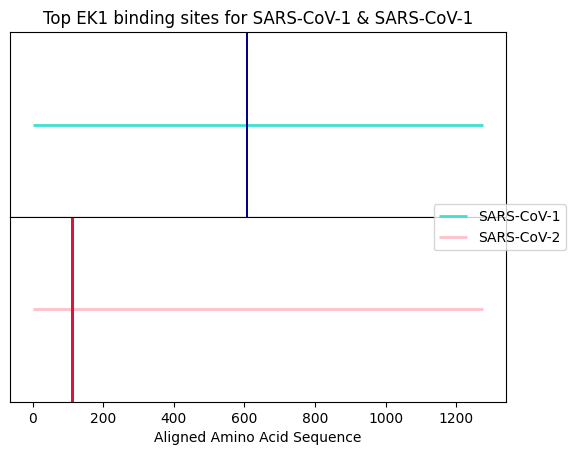

In [153]:
def get_regions(alignment_list, protein_seq):
    max_alignment = max(alignment_list, key=lambda score: score[2])
    motif = max_alignment[0]
    motif = "-*".join(motif)
    
    match = re.search(motif, protein_seq)

    return(match.start(), match.end())
    
global_sars = helper_functions.global_alignment(sars_cov_1_protein, sars_cov_2_protein, helper_functions.blosum62_scoring_function)
aligned_sars_1 = global_sars[0]
aligned_sars_2 = global_sars[1]

# Code involving subplots has been adapted from matplotlib user guide and examples available below at:
# https://matplotlib.org/stable/gallery/index.html
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, (sub1, sub2) = plt.subplots(2, 1, sharex=True)

fig.subplots_adjust(hspace=0)
sub1.set_title('Top EK1 binding sites for SARS-CoV-1 & SARS-CoV-1')

sub1.hlines(y = 0, xmin = 0, xmax = len(aligned_sars_1), color='turquoise', linewidth=2, label='SARS-CoV-1')
sars_1_start, sars_1_end = get_regions(sars_cov_1_motifs, aligned_sars_1)
sub1.hlines(y = 0, xmin = sars_1_start, xmax = sars_1_end, color='darkblue', linewidth=180)
sub1.yaxis.set_visible(False)

sub2.set_xlabel('Aligned Amino Acid Sequence')

sub2.hlines(y = 0, xmin = 0, xmax = len(aligned_sars_1), color='pink', linewidth=2, label='SARS-CoV-2')
sars_2_start, sars_2_end = get_regions(sars_cov_2_motifs, aligned_sars_2)
sub2.hlines(y = 0, xmin = sars_2_start, xmax = sars_2_end, color='crimson', linewidth=180)
sub2.yaxis.set_visible(False)

plt.figlegend(loc='center right')
plt.savefig("problem-bonus.png")
plt.show()

In [ ]:
binding_motif_present = """
Yes, the binding motif is present in the amino acid sequence of SARS-CoV-2. The top sequence is:
- GTTLDSK 
- start: 110, end: 117 (of aligned sequnce)
"""

In [ ]:
binding_motif_similarity = """
The top motifs are somewhat comparable
- SARS-CoV-1 motif: GTNASSE
- SARS-CoV-2 motif: GTTLDSK
There is an approximate 43% match between these motifs.
However, it is interesting to note that bottom 2 motifs have an exact match:
- GSCCKFD and LKGVKLH, but do not contain the exact target amino acid types of 'hpphcpc'
"""

In [ ]:
EK1_drug_efficacy = """
EK1 has shown promising effects within both in-vivo research and clinical trials, whereby targetting the conserved HR1 domain of 
the spike protien, inhibits viral fusion and entry of SARS-CoV-2 into cell (Xiu et al. 2026). Utilising this drug within "cocktail 
therapies" has showcased to have "antiviral synergy", where targetting distinct phases in viral life cycle results in and increased
antiviral effect, and creates a further barrier to genetic resistence (Lan et al. 2021). Furthermore, EK1 has succeffully completed 
clinical Phase I/II trials, where the drug has been administered intranasally resulting in safe and effective therapy, 
highlighting it's feasability (Xiu et al. 2026). Still, limitations remain, whereby rapid acute infection of the virus results in
a limited window for effective therapy, with lack of research within drug-drug interaction and difficulty in delivery routes
highlighting key issues in effective fruther clinical development (Lan et al. 2021, Xiu et al. 2026).

Lan, Q, Wang, C, Zhou, J, Wang, L, Jiao, F, Zhang, Y, Cai, Y, Lu, L, Xia, S & Jiang, S 2021, 
‘25-Hydroxycholesterol-Conjugated EK1 peptide with potent and broad-spectrum inhibitory activity against SARS-CoV-2, its variants of 
concern, and other human coronaviruses’, International journal of molecular sciences, vol. 22, no. 21, p. 11869, 
DOI:10.3390/ijms222111869.
Xiu, R, Wang, Y, Cai, W, Wang, Q, Xie, M, Wang, Y, Li, C, Wang, Q, Huang, J, Ying, T, Song, C, Lu, L, Jiang, S & Xu, W 2026, 
‘Potent in vitro synergistic antiviral effects of the pan-coronavirus fusion inhibitor EK1 in combination with RBD-specific antibodies 
or M PRO inhibitors’, Journal of Virology, vol. 100, no. 4, DOI:10.1128/jvi.00076-26
"""